## Evasion Attack Comparison — NB06b

Aggregates PGD impersonation attack results across all completed dataset runs.

Key metrics:
- **Budget ratio** (PSR): mean ε_min / ε_target across successful pairs — how much of the allowed perturbation budget was actually consumed. A low value (e.g. 0.04) means the attack was very easy: only 4% of the budget was needed. A high value (e.g. 0.75) means the attack had to push closer to the limit.
- **Resistant pairs**: pairs where the attack never crossed the decision boundary within the full ε_target budget. These are excluded (NaN) from the budget ratio but counted in the resistant column.
- **Combo ASR** (Attack Success Rate): fraction of impostor combos where **every** pair in the combo was successfully attacked. An impostor combo consists of K randomly sampled windows from a different subject; ASR=1.0 means 100% of full combos were broken.
- **ε_target**: the attack budget, set to the median intra-subject L2 distance (a "natural step" for that subject's gait).

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

sys.path.insert(0, '../..')

DATASETS     = ['whuGAIT', 'ucihar', 'wisdm', 'combined']
LOG_DIR      = Path('../../logs')
ARTIFACT_DIR = Path('../../artifacts')
TEX_DIR      = Path('../../latex/generated')
OUT_DIR      = Path('../../results/analysis')
OUT_DIR.mkdir(parents=True, exist_ok=True)
TEX_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {'whuGAIT': '#3498db', 'ucihar': '#e74c3c', 'wisdm': '#2ecc71', 'combined': '#9b59b6'}

In [3]:
nb06b = {}
for ds in DATASETS:
    path = ARTIFACT_DIR / ds / f'06b_{ds}_attack_results.npz'
    if not path.exists():
        print(f'  {ds}: 06b results missing — skipping')
        continue
    d = np.load(path, allow_pickle=True)
    succ = d['pair_succeeded'].astype(bool)
    nb06b[ds] = {
        'eps_target':     float(d['eps_target']),
        'pair_psr':       d['pair_psr'],
        'pair_eps_min':   d['pair_eps_min'],
        'pair_actual_l2': d['pair_actual_l2'],
        'pair_succeeded': succ,
        'combo_asr':      d['combo_asr'],
        'combo_eps_min':  d['combo_eps_min'],
    }
    d2 = nb06b[ds]
    psr       = float(np.nanmean(d2['pair_psr']))       # NaN = resistant pair, excluded
    asr       = float(d2['combo_asr'].mean())
    full      = int((d2['combo_asr'] == 1.0).sum())
    resistant = int((~succ).sum())
    ratio     = float((d2['pair_eps_min'][succ] / d2['eps_target']).mean()) if succ.any() else np.nan
    print(f'  {ds}: budget_ratio={psr:.3f}  combo_ASR={asr:.3f}  '
          f'full={full}/{len(d2["combo_asr"])}  resistant={resistant}/{len(succ)}  '
          f'eps_target={d2["eps_target"]:.2f}')

  whuGAIT: budget_ratio=0.056  combo_ASR=1.000  full=220/220  resistant=0/3800  eps_target=24.54
  ucihar: budget_ratio=0.135  combo_ASR=0.980  full=42/72  resistant=106/5000  eps_target=37.47
  wisdm: budget_ratio=0.300  combo_ASR=0.978  full=88/110  resistant=106/5000  eps_target=31.00
  combined: budget_ratio=0.116  combo_ASR=0.962  full=146/182  resistant=125/4000  eps_target=24.11


## Summary table

In [4]:
rows = []
for ds, d in nb06b.items():
    succ = d['pair_succeeded'].astype(bool)
    rows.append({
        'dataset':       ds,
        'eps_target':    round(d['eps_target'], 3),
        'budget_ratio':  round(float(np.nanmean(d['pair_psr'])), 3),   # NaN = resistant pair → excluded
        'combo_ASR':     round(float(d['combo_asr'].mean()), 3),
        'full_combos':   int((d['combo_asr'] == 1.0).sum()),
        'n_combos':      len(d['combo_asr']),
        'resistant':     int((~succ).sum()),
        'n_pairs':       len(succ),
    })

df = pd.DataFrame(rows).set_index('dataset')
print(df.to_string())

          eps_target  budget_ratio  combo_ASR  full_combos  n_combos  resistant  n_pairs
dataset                                                                                 
whuGAIT       24.536         0.056      1.000          220       220          0     3800
ucihar        37.471         0.135      0.980           42        72        106     5000
wisdm         30.998         0.300      0.978           88       110        106     5000
combined      24.113         0.116      0.962          146       182        125     4000


## PSR and combo ASR comparison

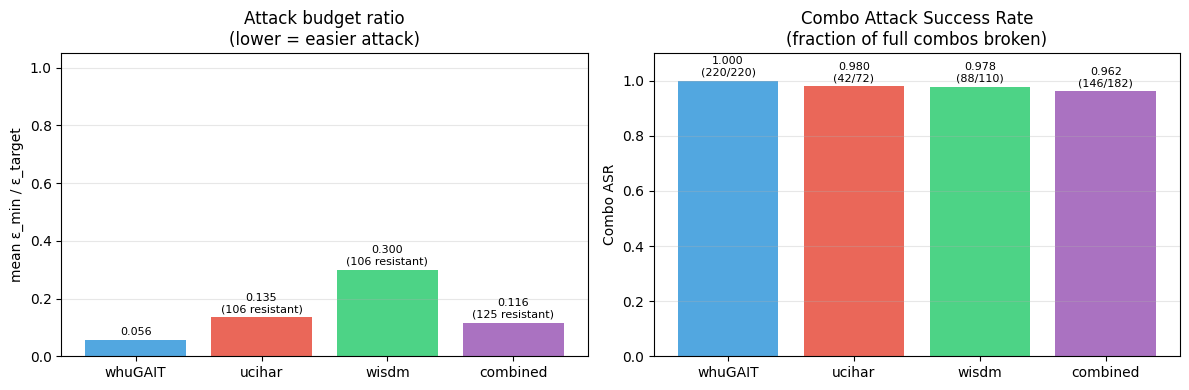

In [5]:
ds_list = list(df.index)
x       = np.arange(len(ds_list))
colors  = [COLORS[ds] for ds in ds_list]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: Budget ratio (PSR) — all datasets (resistant pairs excluded via nanmean)
ax = axes[0]
vals = df['budget_ratio']
bars = ax.bar(x, vals, color=colors, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(ds_list)
ax.set_ylabel('mean ε_min / ε_target')
ax.set_title('Attack budget ratio\n(lower = easier attack)')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
for bar, (v, res) in zip(bars, zip(vals, df['resistant'])):
    label = f'{v:.3f}' + (f'\n({res} resistant)' if res > 0 else '')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            label, ha='center', va='bottom', fontsize=8)

# Panel 2: Combo ASR — all datasets (not filtered by budget ratio)
ax = axes[1]
vals = df['combo_ASR']
bars = ax.bar(x, vals, color=colors, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(ds_list)
ax.set_ylabel('Combo ASR')
ax.set_title('Combo Attack Success Rate\n(fraction of full combos broken)')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')
for bar, (v, f, n) in zip(bars, zip(vals, df['full_combos'], df['n_combos'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.3f}\n({f}/{n})', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'evasion_summary_bars.png', dpi=150)
plt.show()

## Min-budget ε distribution per dataset

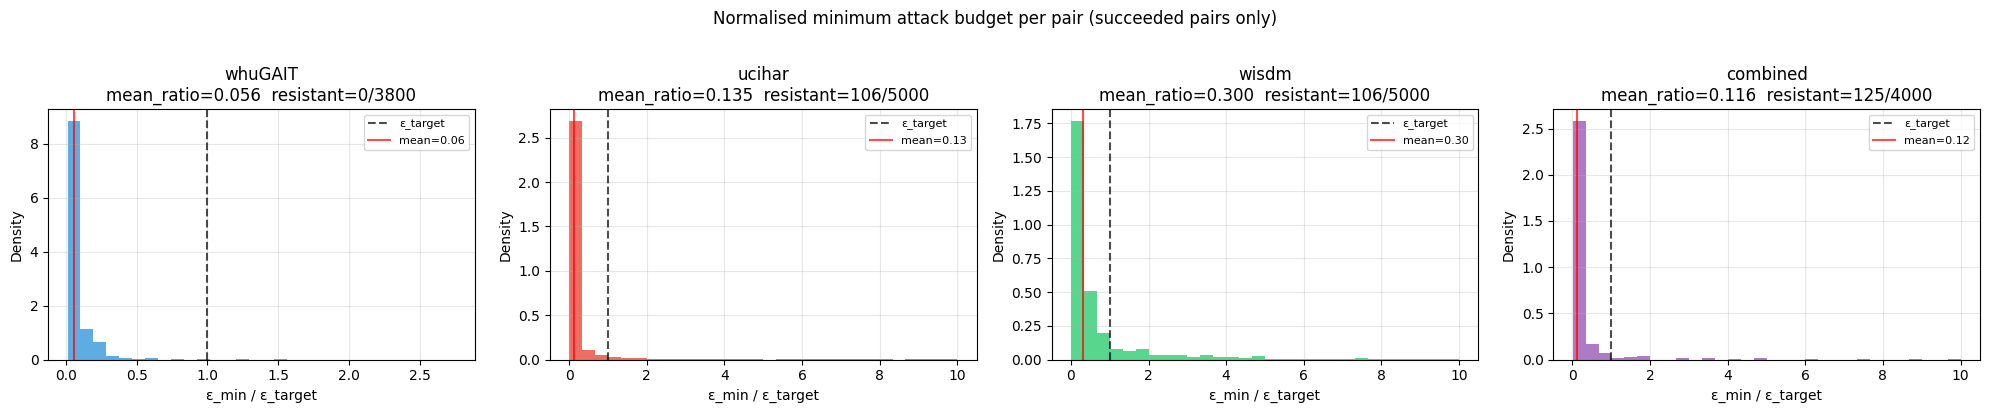

In [6]:
avail_ds = list(nb06b.keys())
fig, axes = plt.subplots(1, len(avail_ds), figsize=(5 * len(avail_ds), 4), sharey=False)
if len(avail_ds) == 1:
    axes = [axes]

for ax, ds in zip(axes, avail_ds):
    d    = nb06b[ds]
    succ = d['pair_succeeded'].astype(bool)
    eps  = d['pair_eps_min'][succ]
    eps_t = d['eps_target']

    ratio = eps / eps_t
    ax.hist(ratio, bins=30, color=COLORS[ds], alpha=0.8, density=True)
    ax.axvline(1.0, ls='--', color='black', alpha=0.7, label='ε_target')
    ax.axvline(float(np.nanmean(d['pair_psr'])), ls='-', color='red', alpha=0.7,
               label=f'mean={float(np.nanmean(d["pair_psr"])):.2f}')
    ax.set_xlabel('ε_min / ε_target')
    ax.set_ylabel('Density')
    resistant = int((~succ).sum())
    ax.set_title(f'{ds}\nmean_ratio={float(np.nanmean(d["pair_psr"])):.3f}  resistant={resistant}/{len(succ)}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Normalised minimum attack budget per pair (succeeded pairs only)', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'evasion_eps_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Training-split attack (overfitting check)

If the training-split PSR is much higher than the test-split PSR, the attack exploits
memorisation in the authenticator rather than a genuine vulnerability.

Test vs training-split attack:
          test budget_ratio  train budget_ratio  test ASR  train ASR
dataset                                                             
whuGAIT               0.056               0.269     1.000      0.914
ucihar                0.135               0.148     0.980      0.970
wisdm                 0.300               0.415     0.978      0.932
combined              0.116               0.454     0.962      0.944


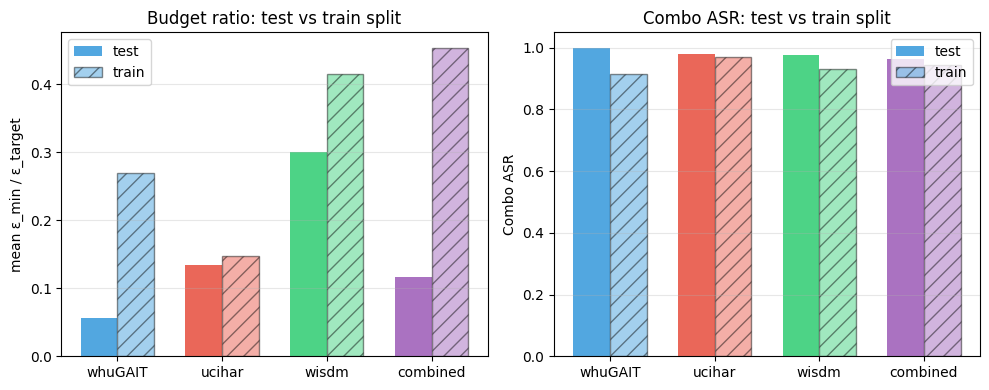

In [7]:
nb06b_train = {}
for ds in DATASETS:
    path = ARTIFACT_DIR / ds / f'06b_{ds}_train_attack_results.npz'
    if not path.exists():
        continue
    d = np.load(path, allow_pickle=True)
    nb06b_train[ds] = {
        'pair_psr':       d['pair_psr'],
        'pair_succeeded': d['pair_succeeded'].astype(bool),
        'combo_asr':      d['combo_asr'],
    }

rows_cmp = []
for ds in DATASETS:
    if ds not in nb06b:
        continue
    test_ratio  = float(np.nanmean(nb06b[ds]['pair_psr'])) if ds in nb06b else np.nan
    train_ratio = float(np.nanmean(nb06b_train[ds]['pair_psr'])) if ds in nb06b_train else np.nan
    test_asr    = float(nb06b[ds]['combo_asr'].mean())
    train_asr   = float(nb06b_train[ds]['combo_asr'].mean()) if ds in nb06b_train else np.nan
    rows_cmp.append({
        'dataset': ds,
        'test budget_ratio':  round(test_ratio, 3),
        'train budget_ratio': round(train_ratio, 3) if not np.isnan(train_ratio) else np.nan,
        'test ASR':   round(test_asr, 3),
        'train ASR':  round(train_asr, 3) if not np.isnan(train_asr) else np.nan,
    })

df_cmp = pd.DataFrame(rows_cmp).set_index('dataset')
print('Test vs training-split attack:')
print(df_cmp.to_string())

# Chart — only plot datasets that have both splits
has_both = [ds for ds in df_cmp.index if not pd.isna(df_cmp.loc[ds, 'train budget_ratio'])]
if has_both:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    x = np.arange(len(has_both))
    w = 0.35

    for ax, (col_test, col_train, ylabel, title) in zip(axes, [
        ('test budget_ratio', 'train budget_ratio', 'mean ε_min / ε_target', 'Budget ratio: test vs train split'),
        ('test ASR', 'train ASR', 'Combo ASR', 'Combo ASR: test vs train split'),
    ]):
        tv = [df_cmp.loc[ds, col_test]  for ds in has_both]
        rv = [df_cmp.loc[ds, col_train] for ds in has_both]
        ax.bar(x - w/2, tv, w, label='test',  color=[COLORS[ds] for ds in has_both], alpha=0.85)
        ax.bar(x + w/2, rv, w, label='train', color=[COLORS[ds] for ds in has_both], alpha=0.45,
               hatch='//', edgecolor='black')
        ax.set_xticks(x); ax.set_xticklabels(has_both)
        ax.set_ylabel(ylabel); ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'evasion_train_vs_test.png', dpi=150)
    plt.show()
else:
    print('No datasets with both splits available — chart skipped.')

In [8]:
from src.utils.latex_writer import write_latex_metrics

def _f(v, fmt='.3f'):
    return f'{v:{fmt}}' if isinstance(v, (int, float)) and not np.isnan(float(v)) else '—'

for ds, d in nb06b.items():
    succ = d['pair_succeeded'].astype(bool)
    n_pairs      = int(len(succ))
    n_resistant  = int((~succ).sum())
    combo_asr    = float(d['combo_asr'].mean())
    budget_ratio = float(np.nanmean(d['pair_psr']))
    eps_target   = float(d['eps_target'])
    full_combos  = int((d['combo_asr'] == 1.0).sum())
    n_combos     = int(len(d['combo_asr']))

    train_asr   = float(nb06b_train[ds]['combo_asr'].mean()) if ds in nb06b_train else np.nan
    train_ratio = float(np.nanmean(nb06b_train[ds]['pair_psr'])) if ds in nb06b_train else np.nan

    prefix = ds.replace('-', '')
    write_latex_metrics(f'compare_evasion_{ds}', {
        'epsTarget':        _f(eps_target, '.2f'),
        'comboASR':         _f(combo_asr),
        'budgetRatio':      _f(budget_ratio),
        'nResistant':       str(n_resistant),
        'nPairs':           str(n_pairs),
        'nFullCombos':      str(full_combos),
        'nCombos':          str(n_combos),
        'trainComboASR':    _f(train_asr),
        'trainBudgetRatio': _f(train_ratio),
    }, output_dir=str(TEX_DIR), key_prefix=prefix)

print(f'LaTeX written to {TEX_DIR}/ (compare_evasion_{{ds}}_metrics.tex)')

LaTeX metrics written: ../../latex/generated/compare_evasion_whuGAIT_metrics.tex
LaTeX metrics written: ../../latex/generated/compare_evasion_ucihar_metrics.tex
LaTeX metrics written: ../../latex/generated/compare_evasion_wisdm_metrics.tex
LaTeX metrics written: ../../latex/generated/compare_evasion_combined_metrics.tex
LaTeX written to ../../latex/generated/ (compare_evasion_{ds}_metrics.tex)
